# Bayesian Optimization of MLP Architectures using JAXBO

This notebook demonstrates the use of **Bayesian Optimization** to find optimal hyperparameters and architecture configurations for a **Multi-Layer Perceptron (MLP)** model using the `jaxbo` package.

## Objectives

- Optimize both **training hyperparameters** (learning rate, weight decay, number of epochs) and **model architecture** (number of layers, neurons per layer, activation functions).
- Track the performance of each candidate architecture.
- Visualize trends in the optimization process (loss evolution, learning rates, layers, activations).

In [ ]:
# Install necessary packages in your virtual environment if not already installed:
# !pip install jax jaxlib optax flax matplotlib seaborn scikit-learn jaxbo

In [32]:
import jax
import jax.numpy as jnp
from jax import random

import numpy as np
import pandas as pd
from flax import linen as nn
import optax

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from jaxbo.models import GP
from jaxbo.input_priors import uniform_prior
from jaxbo.utils import normalize

## Step 1: Generate Synthetic Dataset
We will create a simple regression dataset based on the function z = x² + y², where x and y are sampled uniformly from [-2, 2].

In [3]:
def generate_dataset(n_points=1000, seed=0):
    np.random.seed(seed)
    X = np.random.uniform(-2, 2, size=(n_points, 2))
    y = np.sum(X**2, axis=1, keepdims=True)
    return X, y

X, y = generate_dataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 2: Define the Search Space
Our black-box function will accept a vector of 10 values, which represent:

- Learning rate
- Weight decay
- Number of epochs
- Number of layers
- Neurons in layers 1–3
- Activation functions for layers 1–3 (0: ReLU, 1: Tanh, 2: Sigmoid, 3: GeLu)

In [4]:
# [lr, wd, epochs, num_layers, units_1, units_2, units_3, act_1, act_2, act_3]
lb = jnp.array([1e-5, 0.0,   50.0,  1,  8,  8,  8,  0, 0, 0])
ub = jnp.array([5e-1, 0.2, 2000.0,  5, 256, 256, 256, 3, 3, 3])
bounds = {'lb': lb, 'ub': ub}
dim = 10

# Define uniform prior for GP model
p_x = uniform_prior(lb=lb, ub=ub)

## Step 3: Define Neural Network Model
We use Flax to define a configurable MLP that supports a variable number of layers and activation functions.

In [ ]:
class MLP(nn.Module):
    layers: list
    activations: list

    @nn.compact
    def __call__(self, x):
        for units, act_code in zip(self.layers, self.activations):
            x = nn.Dense(units)(x)
            act_fn = {
                0: nn.relu,
                1: nn.tanh,
                2: nn.sigmoid,
                3: nn.gelu
            }.get(act_code, nn.relu)
            x = act_fn(x)
        return nn.Dense(1)(x)

## Step 4: Decode Parameter Vector

In [6]:
def decode_hyperparams(x: jnp.ndarray):
    lr = float(x[0])
    weight_decay = float(x[1])
    epochs = int(jnp.round(x[2]))
    num_layers = int(jnp.round(x[3]))

    neurons = [int(jnp.round(n)) for n in x[4:4+num_layers]]
    activations = [int(jnp.round(a)) for a in x[7:7+num_layers]]
    
    return lr, weight_decay, epochs, neurons, activations

## Step 5: Define the Objective Function
This function initializes the model, trains it, and returns the penalized validation MSE.

In [7]:
def evaluate_architecture(x, X_train, y_train, X_test, y_test):
    lr, wd, epochs, neurons, activations = decode_hyperparams(x)

    model = MLP(layers=neurons, activations=activations)
    rng = jax.random.PRNGKey(0)
    variables = model.init(rng, jnp.array(X_train))
    optimizer = optax.adamw(lr, weight_decay=wd)
    opt_state = optimizer.init(variables)

    def loss_fn(params, X, y):
        preds = model.apply(params, X)
        return jnp.mean((preds - y) ** 2)

    @jax.jit
    def train_step(params, opt_state, X, y):
        loss, grads = jax.value_and_grad(loss_fn)(params, X, y)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        return optax.apply_updates(params, updates), opt_state, loss

    for _ in range(epochs):
        variables, opt_state, _ = train_step(variables, opt_state, jnp.array(X_train), jnp.array(y_train))

    y_pred = model.apply(variables, jnp.array(X_test))
    mse = jnp.mean((y_pred - y_test) ** 2)
    penalty = 0.01 * sum(neurons)
    return float(mse + penalty)

In [8]:
def black_box_objective(x: jnp.ndarray) -> jnp.ndarray:
    return evaluate_architecture(x, X_train, y_train, X_test, y_test)

## Step 6: Run Bayesian Optimization

In [9]:
rng_key = random.PRNGKey(0)
n_samples = 5
X_init = lb + (ub - lb) * random.uniform(rng_key, shape=(n_samples, dim))
y_init = jnp.array([black_box_objective(x) for x in X_init])

options = {
    'kernel': 'RBF',
    'criterion': 'LCB',
    'input_prior': p_x,
    'kappa': 0.5,
    'nIter': 25
}
gp_model = GP(options)
X, y = X_init, y_init

In [22]:
# Tracking variables
best_ys = []             # best objective value so far
new_ys = []              # new objective value at each iteration
lr_track = []            # learning rates
epoch_track = []         # number of epochs
layer_count_track = []   # number of layers
all_best_activations = []  # activation codes used in best architectures
activation_freq_history = []  # frequency snapshot per iteration

In [23]:
for it in range(options['nIter']):
    print(f"\nIteration {it+1}/{options['nIter']}")

    # Normalize current dataset
    norm_batch, norm_const = normalize(X, y, bounds)
    rng_key, subkey = random.split(rng_key)

    # Train GP model
    params = gp_model.train(norm_batch, subkey, num_restarts=5)

    # Suggest new candidate
    new_X, _, _ = gp_model.compute_next_point_lbfgs(
        num_restarts=5,
        params=params,
        batch=norm_batch,
        norm_const=norm_const,
        bounds=bounds,
        kappa=options['kappa'],
        gmm_vars=None,
        rng_key=subkey
    )

    # Evaluate new candidate
    new_y = jnp.array([black_box_objective(x) for x in new_X])
    new_ys.append(float(new_y[0]))

    # Update dataset
    X = jnp.vstack((X, new_X))
    y = jnp.hstack((y, new_y))

    # Track best result
    best_idx = jnp.argmin(y)
    best_x = X[best_idx]
    best_y = y[best_idx]
    best_ys.append(float(best_y))

    # Decode and track hyperparameters
    lr, wd, epochs, neurons, activations = decode_hyperparams(best_x)
    lr_track.append(lr)
    epoch_track.append(epochs)
    layer_count_track.append(len(neurons))
    all_best_activations.append(activations)

    # Track activation frequency history
    freq = Counter(activations)
    activation_freq_history.append(freq)

    print(f"Best architecture so far: {best_x}")
    print(f"MSE + penalty: {float(best_y):.6f}")



Iteration 1/25
Best architecture so far: [2.8368199e-01 0.0000000e+00 1.5260110e+03 1.2421465e+00 8.0000000e+00
 1.9748947e+02 2.3431473e+02 1.7107227e+00 3.0000000e+00 1.4587500e+00]
MSE + penalty: 0.080486

Iteration 2/25
Best architecture so far: [2.8368199e-01 0.0000000e+00 1.5260110e+03 1.2421465e+00 8.0000000e+00
 1.9748947e+02 2.3431473e+02 1.7107227e+00 3.0000000e+00 1.4587500e+00]
MSE + penalty: 0.080486

Iteration 3/25
Best architecture so far: [2.8368199e-01 0.0000000e+00 1.5260110e+03 1.2421465e+00 8.0000000e+00
 1.9748947e+02 2.3431473e+02 1.7107227e+00 3.0000000e+00 1.4587500e+00]
MSE + penalty: 0.080486

Iteration 4/25
Best architecture so far: [2.8368199e-01 0.0000000e+00 1.5260110e+03 1.2421465e+00 8.0000000e+00
 1.9748947e+02 2.3431473e+02 1.7107227e+00 3.0000000e+00 1.4587500e+00]
MSE + penalty: 0.080486

Iteration 5/25
Best architecture so far: [2.8368199e-01 0.0000000e+00 1.5260110e+03 1.2421465e+00 8.0000000e+00
 1.9748947e+02 2.3431473e+02 1.7107227e+00 3.000000

## Step 7: Show Final Result

In [24]:
best_idx = jnp.argmin(y)
best_x = X[best_idx]
best_y = y[best_idx]
lr, wd, epochs, neurons, activations = decode_hyperparams(best_x)

print("\nBest Hyperparameters Found:")
print(f"Learning rate:   {lr:.6f}")
print(f"Weight decay:    {wd:.6f}")
print(f"Epochs:          {epochs}")
print(f"Num layers:      {len(neurons)}")
print(f"Neurons:         {neurons}")
print(f"Activations:     {activations}")
print(f"Validation loss: {float(best_y):.6f}")


Best Hyperparameters Found:
Learning rate:   0.283682
Weight decay:    0.000000
Epochs:          1526
Num layers:      1
Neurons:         [8]
Activations:     [2]
Validation loss: 0.080486


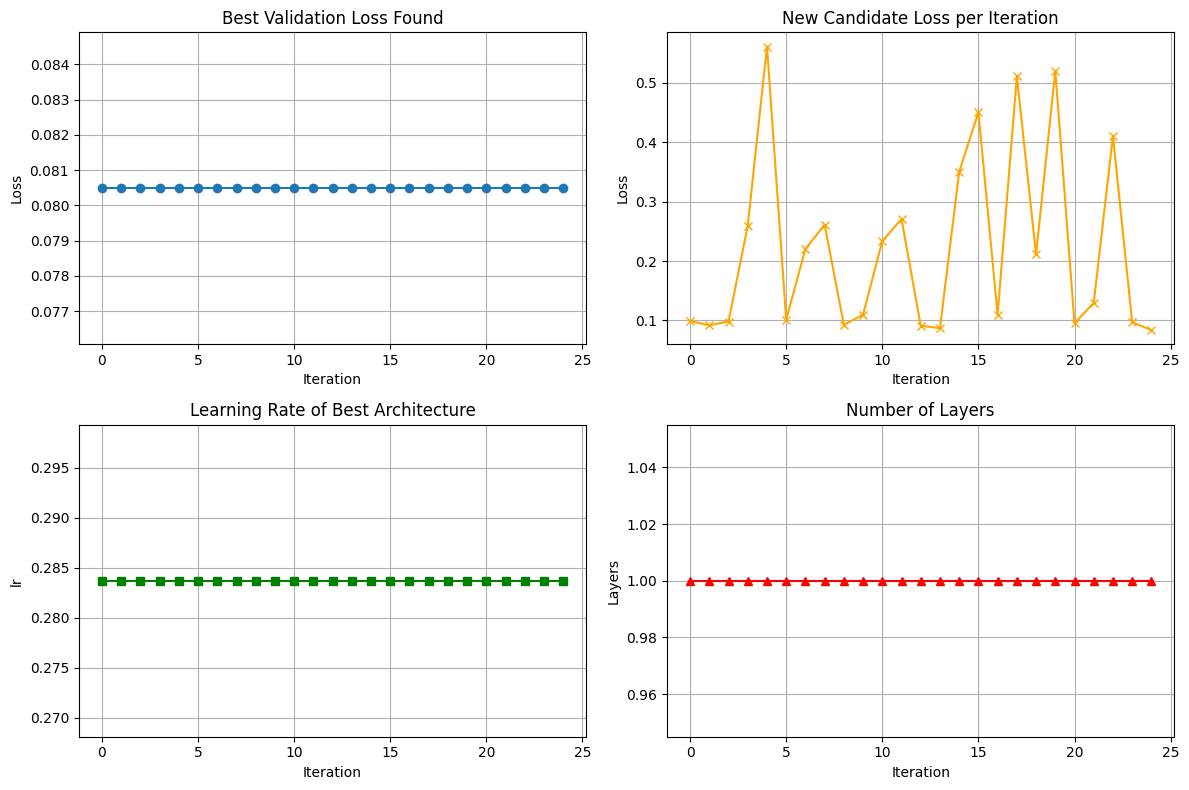

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot best objective value over iterations
axs[0, 0].plot(best_ys, marker='o')
axs[0, 0].set_title("Best Validation Loss Found")
axs[0, 0].set_xlabel("Iteration")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].grid(True)

# Plot new objective value at each iteration
axs[0, 1].plot(new_ys, marker='x', color='orange')
axs[0, 1].set_title("New Candidate Loss per Iteration")
axs[0, 1].set_xlabel("Iteration")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].grid(True)

# Plot learning rate evolution
axs[1, 0].plot(lr_track, marker='s', color='green')
axs[1, 0].set_title("Learning Rate of Best Architecture")
axs[1, 0].set_xlabel("Iteration")
axs[1, 0].set_ylabel("lr")
axs[1, 0].grid(True)

# Plot number of layers
axs[1, 1].plot(layer_count_track, marker='^', color='red')
axs[1, 1].set_title("Number of Layers")
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Layers")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
!pip install pandas

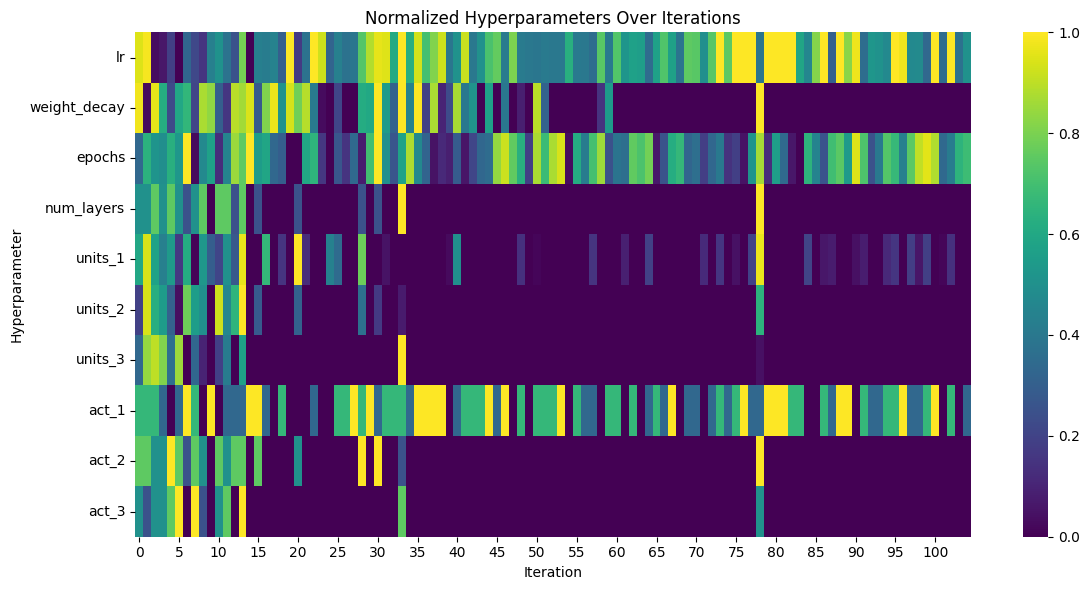

In [33]:

decoded_params = []
for x_vec in X:  # X contains all evaluated points
    lr, wd, epochs, neurons, activations = decode_hyperparams(x_vec)
    decoded_params.append({
        'lr': lr,
        'weight_decay': wd,
        'epochs': epochs,
        'num_layers': len(neurons),
        'units_1': neurons[0] if len(neurons) > 0 else 0,
        'units_2': neurons[1] if len(neurons) > 1 else 0,
        'units_3': neurons[2] if len(neurons) > 2 else 0,
        'act_1': activations[0] if len(activations) > 0 else -1,
        'act_2': activations[1] if len(activations) > 1 else -1,
        'act_3': activations[2] if len(activations) > 2 else -1,
    })

df = pd.DataFrame(decoded_params)

# Normalize all columns for better heatmap readability (0–1 scale)
df_norm = (df - df.min()) / (df.max() - df.min())

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_norm.T, cmap='viridis', cbar=True, xticklabels=5)
plt.title("Normalized Hyperparameters Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Hyperparameter")
plt.tight_layout()
plt.show()
